### Setup and Imports
This cell imports necessary libraries like `pandas` for data manipulation and `numpy` for numerical operations.

In [ ]:
import pandas as pd
import numpy as np

### Mount Google Drive
This cell mounts your Google Drive to access files stored there, specifically the dataset for this notebook.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Define Dataset Path
This cell specifies the file path to the dataset CSV file located on Google Drive.

In [ ]:
file_path = '/content/drive/MyDrive/02-15-2018.csv'

print("Dataset path:")
print(file_path)

Dataset path:
/content/drive/MyDrive/02-15-2018.csv


### Load Dataset
This cell loads the CSV dataset into a pandas DataFrame, setting `low_memory=False` to prevent mixed type warnings.

In [ ]:
print("Loading dataset...")

df = pd.read_csv(
    file_path,
    low_memory=False
)

print("Dataset loaded successfully.")

Loading dataset...
Dataset loaded successfully.


### Display First Rows
This cell displays the first 5 rows of the loaded DataFrame to give a quick overview of the data.

In [ ]:
df.head()

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,15/02/2018 08:25:18,112641158,3,0,0,0,0,0,...,0,0.0,0.000000,0,0,56320579.0,7.042784e+02,56321077,56320081,Benign
1,22,6,15/02/2018 08:29:05,37366762,14,12,2168,2993,712,0,...,32,1024353.0,649038.754495,1601183,321569,11431221.0,3.644991e+06,15617415,8960247,Benign
2,47514,6,15/02/2018 08:29:42,543,2,0,64,0,64,0,...,32,0.0,0.000000,0,0,0.0,0.000000e+00,0,0,Benign
3,0,0,15/02/2018 08:28:07,112640703,3,0,0,0,0,0,...,0,0.0,0.000000,0,0,56320351.5,3.669884e+02,56320611,56320092,Benign
4,0,0,15/02/2018 08:30:56,112640874,3,0,0,0,0,0,...,0,0.0,0.000000,0,0,56320437.0,7.198347e+02,56320946,56319928,Benign


### List Column Names
This cell retrieves and displays all column names present in the DataFrame.

In [ ]:
df.columns.tolist()

['Dst Port',
 'Protocol',
 'Timestamp',
 'Flow Duration',
 'Tot Fwd Pkts',
 'Tot Bwd Pkts',
 'TotLen Fwd Pkts',
 'TotLen Bwd Pkts',
 'Fwd Pkt Len Max',
 'Fwd Pkt Len Min',
 'Fwd Pkt Len Mean',
 'Fwd Pkt Len Std',
 'Bwd Pkt Len Max',
 'Bwd Pkt Len Min',
 'Bwd Pkt Len Mean',
 'Bwd Pkt Len Std',
 'Flow Byts/s',
 'Flow Pkts/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Tot',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Tot',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Bwd PSH Flags',
 'Fwd URG Flags',
 'Bwd URG Flags',
 'Fwd Header Len',
 'Bwd Header Len',
 'Fwd Pkts/s',
 'Bwd Pkts/s',
 'Pkt Len Min',
 'Pkt Len Max',
 'Pkt Len Mean',
 'Pkt Len Std',
 'Pkt Len Var',
 'FIN Flag Cnt',
 'SYN Flag Cnt',
 'RST Flag Cnt',
 'PSH Flag Cnt',
 'ACK Flag Cnt',
 'URG Flag Cnt',
 'CWE Flag Count',
 'ECE Flag Cnt',
 'Down/Up Ratio',
 'Pkt Size Avg',
 'Fwd Seg Size Avg',
 'Bwd Seg Size Avg',
 'Fwd B

### Display DataFrame Information
This cell prints a concise summary of the DataFrame, including the column names, their non-null counts, and data types.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 80 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Dst Port           1048575 non-null  int64  
 1   Protocol           1048575 non-null  int64  
 2   Timestamp          1048575 non-null  object 
 3   Flow Duration      1048575 non-null  int64  
 4   Tot Fwd Pkts       1048575 non-null  int64  
 5   Tot Bwd Pkts       1048575 non-null  int64  
 6   TotLen Fwd Pkts    1048575 non-null  int64  
 7   TotLen Bwd Pkts    1048575 non-null  int64  
 8   Fwd Pkt Len Max    1048575 non-null  int64  
 9   Fwd Pkt Len Min    1048575 non-null  int64  
 10  Fwd Pkt Len Mean   1048575 non-null  float64
 11  Fwd Pkt Len Std    1048575 non-null  float64
 12  Bwd Pkt Len Max    1048575 non-null  int64  
 13  Bwd Pkt Len Min    1048575 non-null  int64  
 14  Bwd Pkt Len Mean   1048575 non-null  float64
 15  Bwd Pkt Len Std    1048575 non-n

### Remove 'Timestamp' Column
This cell drops the 'Timestamp' column from the DataFrame as it is not needed for the subsequent analysis or model training.

In [ ]:
df.drop('Timestamp', axis=1, inplace=True)
print("'Timestamp' column removed successfully.")

'Timestamp' column removed successfully.


### Initial Label Distribution
This cell generates and displays a pie chart showing the distribution of the different labels in the 'Label' column.

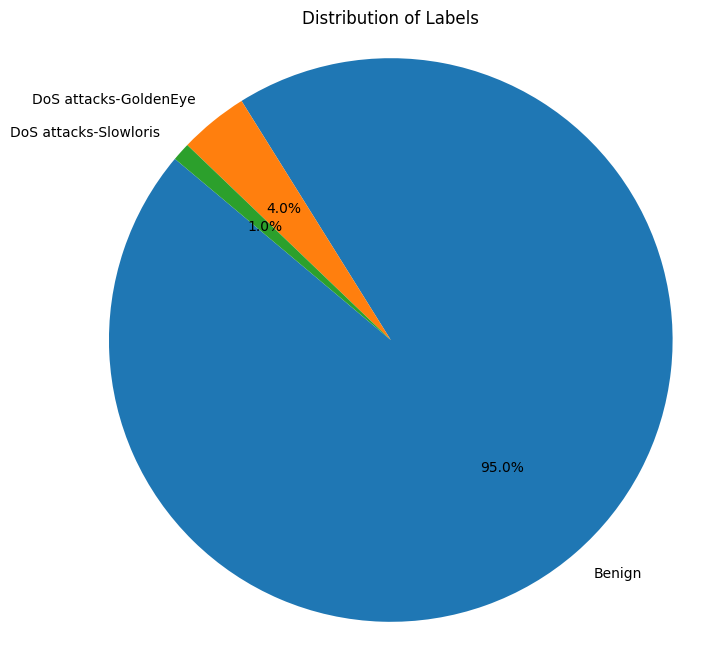

In [ ]:
import matplotlib.pyplot as plt

label_counts = df['Label'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Labels')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

### Remove 'DoS attacks-Slowloris' Label
This cell filters out rows where the 'Label' is 'DoS attacks-Slowloris' and updates the DataFrame, providing a count of removed rows.

In [ ]:
initial_rows = len(df)
df = df[df['Label'] != 'DoS attacks-Slowloris']
removed_rows = initial_rows - len(df)
print(f"Removed {removed_rows} rows labeled 'DoS attacks-Slowloris'.")
print(f"New DataFrame shape: {df.shape}")

Removed 10990 rows labeled 'DoS attacks-Slowloris'.
New DataFrame shape: (1037585, 79)


### Updated Label Distribution
This cell plots the distribution of labels again after removing 'DoS attacks-Slowloris', showing both counts and percentages for clarity.

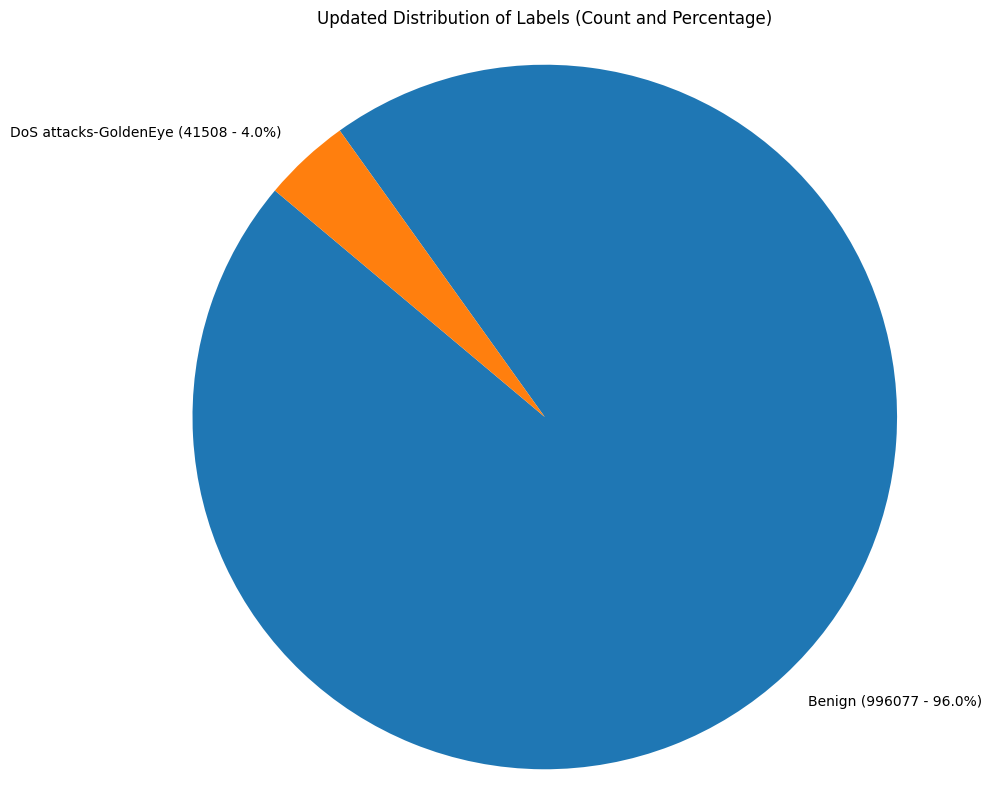

In [ ]:
import matplotlib.pyplot as plt

label_distribution = df['Label'].value_counts()
percentage_distribution = (label_distribution / len(df)) * 100

# Create labels with both count and percentage
labels = [f'{label} ({count} - {percentage:.1f}%)' for label, count, percentage in zip(label_distribution.index, label_distribution.values, percentage_distribution.values)]

plt.figure(figsize=(10, 10))
plt.pie(label_distribution, labels=labels, autopct='', startangle=140, pctdistance=0.85)
plt.title('Updated Distribution of Labels (Count and Percentage)')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

### Check for Duplicate Rows
This cell calculates and displays the number and percentage of duplicate rows in the DataFrame.

In [ ]:
duplicate_rows = df.duplicated().sum()
total_rows = len(df)
duplicate_percentage = (duplicate_rows / total_rows) * 100

print(f"Number of duplicate rows: {duplicate_rows}")
print(f"Total number of rows: {total_rows}")
print(f"Percentage of duplicate rows: {duplicate_percentage:.2f}%")

Number of duplicate rows: 162835
Total number of rows: 1037585
Percentage of duplicate rows: 15.69%


### Display Duplicate Records
This cell prints and displays the actual duplicate rows found in the DataFrame.

In [ ]:
print("Duplicate records:")
duplicate_records = df[df.duplicated()]
display(duplicate_records)

Duplicate records:


,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
12290,80,6,1968873,2,0,0,0,0,0,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,DoS attacks-GoldenEye
13026,80,6,1947540,2,0,0,0,0,0,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,DoS attacks-GoldenEye
13146,80,6,9003609,2,0,0,0,0,0,0.000000,...,32,0.0,0.0,0,0,9003609.0,0.0,9003609,9003609,DoS attacks-GoldenEye
13392,80,6,9000561,2,0,0,0,0,0,0.000000,...,32,0.0,0.0,0,0,9000561.0,0.0,9000561,9000561,DoS attacks-GoldenEye
14374,80,6,1954456,2,0,0,0,0,0,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,DoS attacks-GoldenEye
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048478,80,6,113,2,0,0,0,0,0,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1048488,443,6,142,2,0,0,0,0,0,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1048490,80,6,97,2,0,0,0,0,0,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1048553,443,6,219,3,0,77,0,46,0,25.666667,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign


### Remove Duplicate Rows
This cell removes all identified duplicate rows from the DataFrame, keeping only the first occurrence.

In [ ]:
print("Removing duplicate rows...")
df.drop_duplicates(inplace=True)
print(f"DataFrame now has {len(df)} distinct rows.")

Removing duplicate rows...
DataFrame now has 874750 distinct rows.


### Check for Missing Values
This cell identifies and displays columns that still have missing values after initial cleaning steps.

In [ ]:
print("Missing values in the DataFrame:")
missing_values = df.isnull().sum()
# Display only columns with missing values
display(missing_values[missing_values > 0])

Missing values in the DataFrame:


,0
Flow Byts/s,4759


### Percentage of Missing Values
This cell calculates and displays the percentage of missing values for columns that contain them.

In [ ]:
print("Percentage of missing values in the DataFrame:")
missing_percentage = (missing_values / len(df)) * 100
# Display only columns with missing values and their percentages
display(missing_percentage[missing_percentage > 0])

Percentage of missing values in the DataFrame:


,0
Flow Byts/s,0.544041


### Impute Missing 'Flow Byts/s'
This cell imputes missing values in the 'Flow Byts/s' column using the median value specific to each 'Label' category.

In [ ]:
# Check labels associated with missing 'Flow Byts/s' values
print("Labels for rows with missing 'Flow Byts/s' values:")
display(df[df['Flow Byts/s'].isnull()]['Label'].value_counts())

# Calculate median 'Flow Byts/s' for each label
median_flow_byts_per_label = df.groupby('Label')['Flow Byts/s'].median()
print("\nMedian 'Flow Byts/s' for each label:")
display(median_flow_byts_per_label)

# Impute missing 'Flow Byts/s' values based on the median of their respective label
for label, median_value in median_flow_byts_per_label.items():
    df.loc[(df['Label'] == label) & (df['Flow Byts/s'].isnull()), 'Flow Byts/s'] = median_value

print("\nMissing values in 'Flow Byts/s' imputed successfully.")
# Verify that there are no more missing values in 'Flow Byts/s'
print("\nMissing values after imputation:")
display(df['Flow Byts/s'].isnull().sum())


Labels for rows with missing 'Flow Byts/s' values:


,count
Label,
Benign,4759



Median 'Flow Byts/s' for each label:


,Flow Byts/s
Label,
Benign,1035.553257
DoS attacks-GoldenEye,122.482045



Missing values in 'Flow Byts/s' imputed successfully.

Missing values after imputation:


np.int64(0)

### Handle Infinite Values and Impute
This cell checks for and replaces infinite numerical values with NaN, then imputes these (originally infinite) NaN values using label-wise medians.

In [ ]:
print("Checking for and handling infinite values...")

# Identify numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns

# Check for infinite values in numeric columns
inf_mask = df[numeric_cols].isin([np.inf, -np.inf]).any(axis=1)

if inf_mask.any():
    print("\nRows with infinite values detected. Displaying 'Label' distribution for these rows:")
    # Display value counts of 'Label' for rows with infinite values
    display(df.loc[inf_mask, 'Label'].value_counts())

    # Replace infinite values with NaN
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Identify columns that now have NaN values (originally Inf)
    missing_from_inf_cols = df.columns[df.isnull().any()].tolist()
    missing_from_inf_cols = [col for col in missing_from_inf_cols if col in numeric_cols] # Only consider numeric cols for imputation

    if missing_from_inf_cols:
        print("\nColumns with NaN values (originally Inf) identified:")
        print(missing_from_inf_cols)

        # Impute these new NaN values with the median of their respective columns, grouped by 'Label'
        print("\nImputing NaN values (originally Inf) with median, grouped by 'Label'...")
        for col in missing_from_inf_cols:
            # Calculate median grouped by 'Label'
            median_by_label = df.groupby('Label')[col].transform('median')
            # Fill NaN values using the calculated median specific to each label
            df.loc[:, col] = df.loc[:, col].fillna(median_by_label)
            print(f"  - Imputed column '{col}' with label-wise medians.")
        print("\nInfinite values handled and imputed with label-wise medians successfully.")
    else:
        print("No columns had infinite values that turned into NaNs.")
else:
    print("No infinite values found in the DataFrame.")

# Verify that there are no more missing values introduced by Inf handling
print("\nRemaining missing values after handling Inf:")
remaining_missing = df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]
if not remaining_missing.empty:
    display(remaining_missing)
else:
    print("No remaining missing values.")

Checking for and handling infinite values...

Rows with infinite values detected. Displaying 'Label' distribution for these rows:


,count
Label,
Benign,7712



Columns with NaN values (originally Inf) identified:
['Flow Byts/s', 'Flow Pkts/s']

Imputing NaN values (originally Inf) with median, grouped by 'Label'...
  - Imputed column 'Flow Byts/s' with label-wise medians.
  - Imputed column 'Flow Pkts/s' with label-wise medians.

Infinite values handled and imputed with label-wise medians successfully.

Remaining missing values after handling Inf:
No remaining missing values.


### Final Label Distribution After Cleaning
This cell plots the label distribution one last time after all data cleaning, duplication, and missing/infinite value handling.

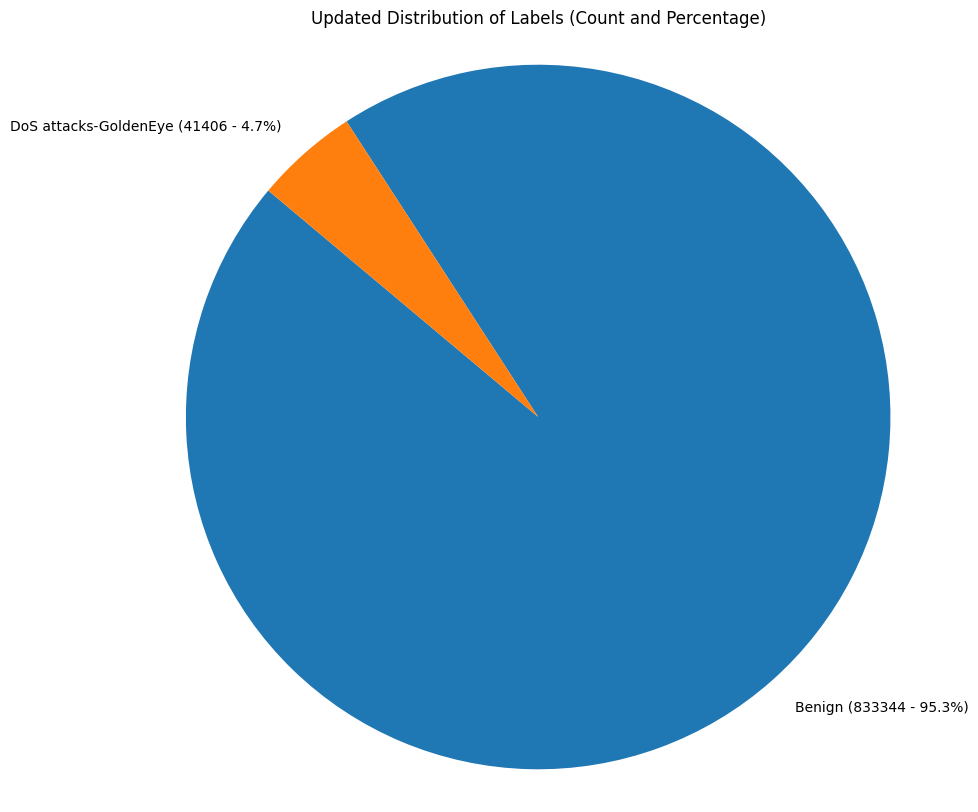

In [ ]:
import matplotlib.pyplot as plt

label_distribution = df['Label'].value_counts()
percentage_distribution = (label_distribution / len(df)) * 100

# Create labels with both count and percentage
labels = [f'{label} ({count} - {percentage:.1f}%)' for label, count, percentage in zip(label_distribution.index, label_distribution.values, percentage_distribution.values)]

plt.figure(figsize=(10, 10))
plt.pie(label_distribution, labels=labels, autopct='', startangle=140, pctdistance=0.85)
plt.title('Updated Distribution of Labels (Count and Percentage)')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

### Prepare Train and Test Datasets
This comprehensive cell orchestrates the creation of training and testing datasets with controlled anomaly rates (0.2%, 1%, 5%). It ensures that benign and attack samples are disjoint between train and test sets and that the anomaly hierarchy is maintained across different anomaly rates within both train and test sets.

In [ ]:
import pandas as pd
import numpy as np
import gc # Import garbage collector

RANDOM_STATE = 42

# Separate benign and attack records from the main DataFrame
benign_records = df[df['Label'] == 'Benign'].copy()
attack_records_goldeneye = df[df['Label'] == 'DoS attacks-GoldenEye'].copy()

print("==================================================")
print("TEST DATA CREATION - BENIGN SAMPLES")
print("==================================================")

N_total_test_size = 50000 # Total size for each test dataset

# Calculate required benign and anomaly counts for each anomaly rate
# For 0.2% anomaly:
N_anomaly_02 = round(N_total_test_size * 0.002)
N_benign_02 = N_total_test_size - N_anomaly_02

# For 1% anomaly:
N_anomaly_1 = round(N_total_test_size * 0.01)
N_benign_1 = N_total_test_size - N_anomaly_1

# For 5% anomaly:
N_anomaly_5 = round(N_total_test_size * 0.05)
N_benign_5 = N_total_test_size - N_anomaly_5

# To ensure "benign data should be common" in the sense of hierarchy (smaller subsets are part of larger),
# we need to sample the largest required benign set first.
max_benign_samples_for_test = max(N_benign_02, N_benign_1, N_benign_5)

# Sample the largest required number of benign samples for the test sets from the available benign records
sampled_benign_for_test = benign_records.sample(n=max_benign_samples_for_test, random_state=RANDOM_STATE)
common_test_benign_pool_original_indices = sampled_benign_for_test.index # Store original indices for non-overlap
common_test_benign_pool_sampled = sampled_benign_for_test.reset_index(drop=True)

del sampled_benign_for_test
gc.collect()

# Create the hierarchical benign test sets by slicing the sampled pool
test_benign_02_percent = common_test_benign_pool_sampled.iloc[:N_benign_02].copy()
test_benign_1_percent = common_test_benign_pool_sampled.iloc[:N_benign_1].copy()
test_benign_5_percent = common_test_benign_pool_sampled.iloc[:N_benign_5].copy()

print(f"Benign test set for 0.2% attacks ({N_benign_02} samples) shape: {test_benign_02_percent.shape}")
print(f"Benign test set for 1% attacks ({N_benign_1} samples) shape: {test_benign_1_percent.shape}")
print(f"Benign test set for 5% attacks ({N_benign_5} samples) shape: {test_benign_5_percent.shape}")

del common_test_benign_pool_sampled
gc.collect()

# Determine the maximum anomaly samples needed to create a superset for attack hierarchy for test sets
max_anomaly_samples_for_test = max(N_anomaly_02, N_anomaly_1, N_anomaly_5)

# Randomly sample the superset of DoS-GoldenEye records for all test attack levels
sampled_attacks_for_test = attack_records_goldeneye.sample(n=max_anomaly_samples_for_test, random_state=RANDOM_STATE)
test_attack_original_indices = sampled_attacks_for_test.index # Store original indices for non-overlap
attack_samples_level3_superset = sampled_attacks_for_test.reset_index(drop=True)

del sampled_attacks_for_test
gc.collect()

# Create hierarchical attack sets by slicing the superset and assigning labels
attacks_L1 = attack_samples_level3_superset.iloc[:N_anomaly_02].copy()
attacks_L1['Label'] = 1

attacks_L2_full = attack_samples_level3_superset.iloc[:N_anomaly_1].copy()
attacks_L2_full.loc[attacks_L2_full.index < N_anomaly_02, 'Label'] = 1
attacks_L2_full.loc[attacks_L2_full.index >= N_anomaly_02, 'Label'] = 2

attacks_L3_full = attack_samples_level3_superset.iloc[:N_anomaly_5].copy()
attacks_L3_full.loc[attacks_L3_full.index < N_anomaly_02, 'Label'] = 1
attacks_L3_full.loc[(attacks_L3_full.index >= N_anomaly_02) & (attacks_L3_full.index < N_anomaly_1), 'Label'] = 2
attacks_L3_full.loc[attacks_L3_full.index >= N_anomaly_1, 'Label'] = 3

print(f"Attack samples for 0.2% dataset (L1, {attacks_L1.shape[0]} samples) shape: {attacks_L1.shape}")
print(f"Attack samples for 1% dataset (L1+L2, {attacks_L2_full.shape[0]} samples) shape: {attacks_L2_full.shape}")
print(f"Attack samples for 5% dataset (L1+L2+L3, {attacks_L3_full.shape[0]} samples) shape: {attacks_L3_full.shape}")

del attack_samples_level3_superset
gc.collect()

# 4. Construct Final Test Datasets (total 50k samples each)
test_df_02 = pd.concat([test_benign_02_percent, attacks_L1]).reset_index(drop=True)
test_df_1 = pd.concat([test_benign_1_percent, attacks_L2_full]).reset_index(drop=True)
test_df_5 = pd.concat([test_benign_5_percent, attacks_L3_full]).reset_index(drop=True)

# Clean up intermediate test dataframes
del test_benign_02_percent, test_benign_1_percent, test_benign_5_percent
del attacks_L1, attacks_L2_full, attacks_L3_full
gc.collect()

print("\nTest dataset shapes:")
print(f"  0.2% Test dataset shape: {test_df_02.shape}")
print(f"  1% Test dataset shape: {test_df_1.shape}")
print(f"  5% Test dataset shape: {test_df_5.shape}")

print("\nClass distributions:")
print("  0.2% Test dataset class distribution:\n" + str(test_df_02['Label'].value_counts()))
print("  1% Test dataset class distribution:\n" + str(test_df_1['Label'].value_counts()))
print("  5% Test dataset class distribution:\n" + str(test_df_5['Label'].value_counts()))

print("\nPercentage distributions:")
print("  0.2% Test dataset percentage distribution:\n" + str(test_df_02['Label'].value_counts(normalize=True) * 100))
print("  1% Test dataset percentage distribution:\n" + str(test_df_1['Label'].value_counts(normalize=True) * 100))
print("  5% Test dataset percentage distribution:\n" + str(test_df_5['Label'].value_counts(normalize=True) * 100))

print("\n==================================================")
print("TRAINING DATA CREATION - REMAINING SAMPLES")
print("==================================================")

# Identify benign records not used in test sets for training
train_benign_pool_all = benign_records[~benign_records.index.isin(common_test_benign_pool_original_indices)].copy()
# Identify attack records not used in test sets for training
train_attack_pool_all = attack_records_goldeneye[~attack_records_goldeneye.index.isin(test_attack_original_indices)].copy()

# Calculate the actual number of available benign and attack samples for training
available_benign_for_train = len(train_benign_pool_all)
available_attack_for_train = len(train_attack_pool_all)

# Determine the maximum total training size that can be achieved for the 5% anomaly rate
# given the available attack samples and benign samples. This will be the common size for all train sets.
max_total_size_by_attack_limit = available_attack_for_train / 0.05 if 0.05 > 0 else float('inf')
max_total_size_by_benign_limit = available_benign_for_train / 0.95 if 0.95 > 0 else float('inf')

# The N_total_train_size should be the minimum of these limits, rounded down.
# This ensures that all required benign and anomaly samples can be drawn for all anomaly rates.
N_total_train_size = int(min(max_total_size_by_attack_limit, max_total_size_by_benign_limit))

print(f"Adjusted N_total_train_size to ensure all train datasets have the same size and proportions: {N_total_train_size}")

# Calculate required benign and anomaly counts for each anomaly rate for training sets
train_N_anomaly_02 = round(N_total_train_size * 0.002)
train_N_benign_02 = N_total_train_size - train_N_anomaly_02

train_N_anomaly_1 = round(N_total_train_size * 0.01)
train_N_benign_1 = N_total_train_size - train_N_anomaly_1

train_N_anomaly_5 = round(N_total_train_size * 0.05)
train_N_benign_5 = N_total_train_size - train_N_anomaly_5

# To ensure "benign data should be common" in the sense of hierarchy for training,
# we need to sample the largest required benign set first from the available training benign pool.
train_max_benign_samples = train_N_benign_02 # This is the largest benign count needed

# Sample indices from the available training benign pool
common_train_benign_pool_sampled_indices = train_benign_pool_all.sample(n=train_max_benign_samples, random_state=RANDOM_STATE).index

# Create hierarchical benign training sets using loc and reset_index once
train_benign_02_percent = train_benign_pool_all.loc[common_train_benign_pool_sampled_indices[:train_N_benign_02]].reset_index(drop=True)
train_benign_1_percent = train_benign_pool_all.loc[common_train_benign_pool_sampled_indices[:train_N_benign_1]].reset_index(drop=True)
train_benign_5_percent = train_benign_pool_all.loc[common_train_benign_pool_sampled_indices[:train_N_benign_5]].reset_index(drop=True)

print(f"Benign train set for 0.2% attacks ({train_N_benign_02} samples) shape: {train_benign_02_percent.shape}")
print(f"Benign train set for 1% attacks ({train_N_benign_1} samples) shape: {train_benign_1_percent.shape}")
print(f"Benign train set for 5% attacks ({train_N_benign_5} samples) shape: {train_benign_5_percent.shape}")

del common_train_benign_pool_sampled_indices, train_benign_pool_all
gc.collect()

# Determine the maximum anomaly samples needed for training (for 5% anomaly rate)
train_max_anomaly_samples = train_N_anomaly_5

# Sample the superset of DoS-GoldenEye records for all training attack levels
train_attack_samples_superset = train_attack_pool_all.sample(n=train_max_anomaly_samples, random_state=RANDOM_STATE).reset_index(drop=True)

# These are already the "actual" counts because N_total_train_size was adjusted
train_N_anomaly_02_actual = train_N_anomaly_02
train_N_anomaly_1_actual = train_N_anomaly_1
train_N_anomaly_5_actual = train_N_anomaly_5

# Level 1 attacks for training: train_N_anomaly_02_actual records, labeled 1
train_attacks_L1 = train_attack_samples_superset.iloc[:train_N_anomaly_02_actual].copy()
train_attacks_L1['Label'] = 1

# Level 2 attacks for training: Total train_N_anomaly_1_actual records, labeled 2 (additional) or 1 (from L1)
train_attacks_L2_full = train_attack_samples_superset.iloc[:train_N_anomaly_1_actual].copy()
train_attacks_L2_full.loc[train_attacks_L2_full.index < train_N_anomaly_02_actual, 'Label'] = 1
train_attacks_L2_full.loc[train_attacks_L2_full.index >= train_N_anomaly_02_actual, 'Label'] = 2

# Level 3 attacks for training: Total train_N_anomaly_5_actual records, labeled 3 (additional) or 1/2 (from L1/L2)
train_attacks_L3_full = train_attack_samples_superset.iloc[:train_N_anomaly_5_actual].copy()
train_attacks_L3_full.loc[train_attacks_L3_full.index < train_N_anomaly_02_actual, 'Label'] = 1
train_attacks_L3_full.loc[(train_attacks_L3_full.index >= train_N_anomaly_02_actual) & (train_attacks_L3_full.index < train_N_anomaly_1_actual), 'Label'] = 2
train_attacks_L3_full.loc[train_attacks_L3_full.index >= train_N_anomaly_1_actual, 'Label'] = 3

print(f"Attack samples for 0.2% train dataset (L1, {train_attacks_L1.shape[0]} samples) shape: {train_attacks_L1.shape}")
print(f"Attack samples for 1% train dataset (L1+L2, {train_attacks_L2_full.shape[0]} samples) shape: {train_attacks_L2_full.shape}")
print(f"Attack samples for 5% train dataset (L1+L2+L3, {train_attacks_L3_full.shape[0]} samples) shape: {train_attacks_L3_full.shape}")

del train_attack_samples_superset, train_attack_pool_all
gc.collect()

# Construct Final Training Datasets (total N_total_train_size samples each)
train_df_02 = pd.concat([train_benign_02_percent, train_attacks_L1]).reset_index(drop=True)
train_df_1 = pd.concat([train_benign_1_percent, train_attacks_L2_full]).reset_index(drop=True)
train_df_5 = pd.concat([train_benign_5_percent, train_attacks_L3_full]).reset_index(drop=True)

# Clean up intermediate training dataframes
del train_benign_02_percent, train_benign_1_percent, train_benign_5_percent
del train_attacks_L1, train_attacks_L2_full, train_attacks_L3_full

del benign_records, attack_records_goldeneye # Delete the initial large DFs once no longer needed
gc.collect()

print("\nTrain dataset shapes:")
print(f"  0.2% Train dataset shape: {train_df_02.shape}")
print(f"  1% Train dataset shape: {train_df_1.shape}")
print(f"  5% Train dataset shape: {train_df_5.shape}")

print("\nTrain Class distributions:")
print("  0.2% Train dataset class distribution:\n" + str(train_df_02['Label'].value_counts()))
print("  1% Train dataset class distribution:\n" + str(train_df_1['Label'].value_counts()))
print("  5% Train dataset class distribution:\n" + str(train_df_5['Label'].value_counts()))

print("\nTrain Percentage distributions:")
print("  0.2% Train dataset percentage distribution:\n" + str(train_df_02['Label'].value_counts(normalize=True) * 100))
print("  1% Train dataset percentage distribution:\n" + str(train_df_1['Label'].value_counts(normalize=True) * 100))
print("  5% Train dataset percentage distribution:\n" + str(train_df_5['Label'].value_counts(normalize=True) * 100))


print("\n==================================================")
print("VERIFICATION")
print("==================================================")

# Verification that train and test normal samples are disjoint
overlap_train_test_benign = pd.merge(train_df_02[train_df_02['Label'] == 'Benign'].drop(columns=['Label'], errors='ignore'),
                                     test_df_02[test_df_02['Label'] == 'Benign'].drop(columns=['Label'], errors='ignore'),
                                     how='inner', on=list(df.drop(columns=['Label'], errors='ignore').columns)).shape[0]
print(f"Overlap between training benign and largest test benign set: {overlap_train_test_benign} records. (Expected: 0)")

# Verification that benign test records are identical across test datasets (hierarchical requirement)
# To verify hierarchy, we need to compare the actual benign samples. Re-extract them from final DFs.
re_test_benign_02 = test_df_02[test_df_02['Label'] == 'Benign'].drop(columns=['Label'], errors='ignore')
re_test_benign_1 = test_df_1[test_df_1['Label'] == 'Benign'].drop(columns=['Label'], errors='ignore')
re_test_benign_5 = test_df_5[test_df_5['Label'] == 'Benign'].drop(columns=['Label'], errors='ignore')

is_5_in_1 = re_test_benign_5.shape[0] == pd.merge(re_test_benign_5, re_test_benign_1, on=list(df.drop(columns=['Label'], errors='ignore').columns), how='inner').shape[0]
is_1_in_02 = re_test_benign_1.shape[0] == pd.merge(re_test_benign_1, re_test_benign_02, on=list(df.drop(columns=['Label'], errors='ignore').columns), how='inner').shape[0]
print(f"Are all {re_test_benign_5.shape[0]} benign samples in {re_test_benign_1.shape[0]} benign samples? {is_5_in_1}")
print(f"Are all {re_test_benign_1.shape[0]} benign samples in {re_test_benign_02.shape[0]} benign samples? {is_1_in_02}")

# Verification that attack hierarchy is satisfied for test sets
# Re-extract attacks with their original labels from the final DFs for verification
re_test_attacks_L1 = test_df_02[test_df_02['Label'] == 1].drop(columns=['Label'], errors='ignore')
re_test_attacks_L2_full = test_df_1[test_df_1['Label'].isin([1,2])].drop(columns=['Label'], errors='ignore')
re_test_attacks_L3_full = test_df_5[test_df_5['Label'].isin([1,2,3])].drop(columns=['Label'], errors='ignore')

is_L1_in_L2_test = re_test_attacks_L1.shape[0] == pd.merge(re_test_attacks_L1, re_test_attacks_L2_full, on=list(df.drop(columns=['Label'], errors='ignore').columns), how='inner').shape[0]
is_L2_in_L3_test = re_test_attacks_L2_full.shape[0] == pd.merge(re_test_attacks_L2_full, re_test_attacks_L3_full, on=list(df.drop(columns=['Label'], errors='ignore').columns), how='inner').shape[0]
print(f"Are all Level 1 attacks in Level 2 attacks (Test)? {is_L1_in_L2_test}")
print(f"Are all Level 2 attacks in Level 3 attacks (Test)? {is_L2_in_L3_test}")

# Verify attack labels within each test dataset
print("\nAttack label verification (Test sets):")
print(f"  Labels in 0.2% test attacks: {test_df_02[test_df_02['Label'] != 'Benign']['Label'].unique()}")
print(f"  Labels in 1% test attacks: {test_df_1[test_df_1['Label'] != 'Benign']['Label'].unique()}")
print(f"  Labels in 5% test attacks: {test_df_5[test_df_5['Label'] != 'Benign']['Label'].unique()}")

# Verification that benign training records are identical across train datasets (hierarchical requirement)
# Re-extract them from final DFs for verification.
re_train_benign_02 = train_df_02[train_df_02['Label'] == 'Benign'].drop(columns=['Label'], errors='ignore')
re_train_benign_1 = train_df_1[train_df_1['Label'] == 'Benign'].drop(columns=['Label'], errors='ignore')
re_train_benign_5 = train_df_5[train_df_5['Label'] == 'Benign'].drop(columns=['Label'], errors='ignore')

is_train_5_in_1 = re_train_benign_5.shape[0] == pd.merge(re_train_benign_5, re_train_benign_1, on=list(df.drop(columns=['Label'], errors='ignore').columns), how='inner').shape[0]
is_train_1_in_02 = re_train_benign_1.shape[0] == pd.merge(re_train_benign_1, re_train_benign_02, on=list(df.drop(columns=['Label'], errors='ignore').columns), how='inner').shape[0]
print(f"\nAre all {re_train_benign_5.shape[0]} benign samples in {re_train_benign_1.shape[0]} benign samples (Train)? {is_train_5_in_1}")
print(f"Are all {re_train_benign_1.shape[0]} benign samples in {re_train_benign_02.shape[0]} benign samples (Train)? {is_train_1_in_02}")

# Verification that attack hierarchy is satisfied for training sets
# Re-extract attacks with their original labels from the final DFs for verification
re_train_attacks_L1 = train_df_02[train_df_02['Label'] == 1].drop(columns=['Label'], errors='ignore')
re_train_attacks_L2_full = train_df_1[train_df_1['Label'].isin([1,2])].drop(columns=['Label'], errors='ignore')
re_train_attacks_L3_full = train_df_5[train_df_5['Label'].isin([1,2,3])].drop(columns=['Label'], errors='ignore')

is_L1_in_L2_train = re_train_attacks_L1.shape[0] == pd.merge(re_train_attacks_L1, re_train_attacks_L2_full, on=list(df.drop(columns=['Label'], errors='ignore').columns), how='inner').shape[0]
is_L2_in_L3_train = re_train_attacks_L2_full.shape[0] == pd.merge(re_train_attacks_L2_full, re_train_attacks_L3_full, on=list(df.drop(columns=['Label'], errors='ignore').columns), how='inner').shape[0]
print(f"Are all Level 1 attacks in Level 2 attacks (Train)? {is_L1_in_L2_train}")
print(f"Are all Level 2 attacks in Level 3 attacks (Train)? {is_L2_in_L3_train}")

# Verify attack labels within each train dataset
print("\nAttack label verification (Train sets):")
print(f"  Labels in 0.2% train attacks: {train_df_02[train_df_02['Label'] != 'Benign']['Label'].unique()}")
print(f"  Labels in 1% train attacks: {train_df_1[train_df_1['Label'] != 'Benign']['Label'].unique()}")
print(f"  Labels in 5% train attacks: {train_df_5[train_df_5['Label'] != 'Benign']['Label'].unique()}")

TEST DATA CREATION - BENIGN SAMPLES
Benign test set for 0.2% attacks (49900 samples) shape: (49900, 79)
Benign test set for 1% attacks (49500 samples) shape: (49500, 79)
Benign test set for 5% attacks (47500 samples) shape: (47500, 79)
Attack samples for 0.2% dataset (L1, 100 samples) shape: (100, 79)
Attack samples for 1% dataset (L1+L2, 500 samples) shape: (500, 79)
Attack samples for 5% dataset (L1+L2+L3, 2500 samples) shape: (2500, 79)

Test dataset shapes:
  0.2% Test dataset shape: (50000, 79)
  1% Test dataset shape: (50000, 79)
  5% Test dataset shape: (50000, 79)

Class distributions:
  0.2% Test dataset class distribution:
Label
Benign    49900
1           100
Name: count, dtype: int64
  1% Test dataset class distribution:
Label
Benign    49500
2           400
1           100
Name: count, dtype: int64
  5% Test dataset class distribution:
Label
Benign    47500
3          2000
2           400
1           100
Name: count, dtype: int64

Percentage distributions:
  0.2% Test data

### Autoencoder Experiment Pipeline Setup
This cell initializes the environment, sets up constants, and defines all necessary utility functions for the autoencoder experiments. This includes functions for metrics computation, safe Yeo-Johnson transformation, feature selection, preprocessing, autoencoder model building, and Optuna-based hyperparameter optimization. It also applies a fix for degenerate thresholding.

In [ ]:
# ============================================================================
# CICIDS2018 AUTOENCODER - 4-EXPERIMENT PIPELINE v4 (BEST + 2ND-BEST HPO)
# Same process/logic/presentation as v3: rate-anchored thresholding,
# MI-weighted reconstruction error, SafeYeoJohnson, wide Optuna search,
# training on the full contaminated data as provided (TRAIN_CONTAM).
#
# NEW IN THIS VERSION:
#   1. For Exp 3 and Exp 4 (the HPO experiments), BOTH the best AND the
#      second-best Optuna trial are retrained into full models and
#      cross-tested on all 3 test sets -- so you can directly compare
#      "Best HPO" vs "2nd-Best HPO" performance, not just the single winner.
#   2. Fixed the zero-value (Precision=0/Recall=0/F1=0) degenerate-threshold
#      bug: tune_rate_multiplier() no longer selects a multiplier that
#      predicts ZERO positives if any other multiplier in the grid predicts
#      at least one -- a threshold that flags nothing was previously able to
#      "win" on composite score purely by having FPR=0, which is a false
#      victory.
#   3. Every (Experiment, TrainSet, Rank) combination is wrapped in its own
#      try/except so a single failure never stops the whole run.
# ============================================================================
import os, gc, json, time, warnings, traceback
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)

from sklearn.preprocessing import MinMaxScaler, PowerTransformer
from sklearn.feature_selection import mutual_info_classif, VarianceThreshold
from sklearn.model_selection import train_test_split
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix)
from scipy.stats import skew

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers

try:
    import optuna
except ImportError:
    os.system("pip -q install optuna")
    import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import joblib

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

SAVE_DIR = "/content/ae_models_v4_bestsecond"
os.makedirs(SAVE_DIR, exist_ok=True)
RESULTS_CSV_PATH = os.path.join(SAVE_DIR, "all_experiments_results.csv")

# Optimized for 8 GB Google Colab RAM -- unchanged from your pasted script
CHUNK_SIZE           = 10000
N_SELECTED_FEATURES  = 35
N_OPTUNA_TRIALS      = 40
HPO_SUBSAMPLE        = 40000
HPO_EPOCHS           = 15
HPO_PATIENCE         = 4
FINAL_EPOCHS         = 80
FINAL_PATIENCE       = 8
BATCH_SIZE           = 256
CAL_FRACTION_FOR_HPO = 0.25
MULT_SEARCH_GRID     = np.geomspace(0.2, 4.0, 40)
CONTAM_FIT_MAX_ROWS  = 300000

def close_figs():
    plt.close("all")

print("Setup complete. TensorFlow:", tf.__version__)


# %% CELL 1 -- SANITY CHECK -------------------------------------------------
REQUIRED = ["train_df_02", "train_df_1", "train_df_5",
            "test_df_02", "test_df_1", "test_df_5"]
missing = [v for v in REQUIRED if v not in globals()]
if missing:
    raise NameError(f"Missing variables from earlier cells: {missing}")

all_dfs = [train_df_02, train_df_1, train_df_5, test_df_02, test_df_1, test_df_5]
for name, df in zip(["train_df_02","train_df_1","train_df_5","test_df_02","test_df_1","test_df_5"], all_dfs):
    assert "Label" in df.columns, f"{name} is missing the Label column"
print("Sanity check passed.")


# %% CELL 2 -- LABEL EXTRACTION + TRAIN(CONTAM-RATIO) / TEST(FULL) BUILD -----
common_cols = set(train_df_02.columns)
for d in [train_df_1, train_df_5, test_df_02, test_df_1, test_df_5]:
    common_cols &= set(d.columns)
train_cols = sorted([c for c in common_cols if c != "Label"
                      and pd.api.types.is_numeric_dtype(train_df_02[c])])
print(f"{len(train_cols)} common numeric feature columns.")

def split_labels_and_features(df, name):
    y = (df["Label"].astype(str).str.strip() != "Benign").astype(int).values
    print(f"  [{name}] {y.sum()} anomalies / {len(y)} rows "
          f"({100*y.sum()/len(y):.3f}% contamination)")
    X = df[train_cols].copy()
    return X, y

X_test_02, y_test_02 = split_labels_and_features(test_df_02, "test_df_02")
X_test_1,  y_test_1  = split_labels_and_features(test_df_1,  "test_df_1")
X_test_5,  y_test_5  = split_labels_and_features(test_df_5,  "test_df_5")

TEST_FULL  = {"0.2%": (X_test_02.reset_index(drop=True), y_test_02),
              "1%":   (X_test_1.reset_index(drop=True),  y_test_1),
              "5%":   (X_test_5.reset_index(drop=True),  y_test_5)}
TRUE_RATES = {"0.2%": 0.002, "1%": 0.01, "5%": 0.05}

def build_contaminated_fit_set(df, name, seed=SEED):
    y = (df["Label"].astype(str).str.strip() != "Benign").astype(int).values
    if len(df) > CONTAM_FIT_MAX_ROWS:
        idx = pd.Series(y).groupby(y).sample(n=None, frac=CONTAM_FIT_MAX_ROWS/len(df), random_state=seed).index
        if len(idx) > CONTAM_FIT_MAX_ROWS:
            idx = idx[:CONTAM_FIT_MAX_ROWS]
        X_fit = df.iloc[idx][train_cols].reset_index(drop=True)
        y_fit = y[idx]
    else:
        X_fit = df[train_cols].reset_index(drop=True)
        y_fit = y
    print(f"  [{name}] contaminated training rows sampled: {len(X_fit)} (Anomalies: {np.sum(y_fit)})")
    return X_fit

TRAIN_CONTAM = {
    "0.2%": build_contaminated_fit_set(train_df_02, "train_df_02"),
    "1%":   build_contaminated_fit_set(train_df_1,  "train_df_1"),
    "5%":   build_contaminated_fit_set(train_df_5,  "train_df_5"),
}
print("\nTraining separate model(s) per TrainSet; each cross-tested on ALL THREE test sets.")


# %% CELL 3 -- STRATIFIED SLICE PER TEST SET FOR HPO/THRESHOLD-MULTIPLIER --
HPO_CAL = {}
for name, (X, y) in TEST_FULL.items():
    X_hpo, _, y_hpo, _ = train_test_split(
        X, y, train_size=CAL_FRACTION_FOR_HPO, stratify=y, random_state=SEED
    )
    HPO_CAL[name] = (X_hpo.reset_index(drop=True), y_hpo)
    print(f"  [{name}] HPO-guidance slice: {len(y_hpo)} rows, {y_hpo.sum()} anomalies")


# %% CELL 4 -- METRICS UTILITIES (with degenerate-threshold fix) -----------
def composite_score(f1, fpr, fnr):
    return f1 - 0.10 * fpr - 0.05 * fnr

def compute_metrics(y_true, y_pred, scores=None):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    auc = np.nan
    if scores is not None:
        try:
            auc = roc_auc_score(y_true, scores)
        except Exception:
            pass
    return {"Precision": precision, "Recall": recall, "F1": f1, "FPR": fpr, "FNR": fnr,
            "AUC": auc, "TP": int(tp), "FP": int(fp), "FN": int(fn), "TN": int(tn)}

def print_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    print(f"\nConfusion matrix - {title}")
    print(f"{'':15}{'Pred: Benign':>15}{'Pred: Attack':>15}")
    print(f"{'Actual: Benign':15}{cm[0,0]:>15}{cm[0,1]:>15}")
    print(f"{'Actual: Attack':15}{cm[1,0]:>15}{cm[1,1]:>15}")

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    fig, ax = plt.subplots(figsize=(4, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Benign", "Attack"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Benign", "Attack"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(title, fontsize=9)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max()/2 else "black")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout(); plt.show()
    close_figs()

def rate_anchored_threshold(scores, assumed_rate):
    pct = 100 * (1 - min(max(assumed_rate, 1e-6), 0.5))
    return np.percentile(scores, pct)

def tune_rate_multiplier(cal_scores, y_cal, base_rate, grid=MULT_SEARCH_GRID):
    """
    FIX for the zero-value bug: previously, a multiplier that predicted ZERO
    positives could still "win" on composite score (FPR=0 masks the fact
    that F1=0 too). Now: any candidate with at least 1 predicted positive is
    strictly preferred over one with none. Only if EVERY candidate in the
    grid predicts zero positives do we fall back to the loosest threshold
    (smallest multiplier), which at least gives the model a chance to flag
    something rather than silently predicting "no attacks" everywhere.
    """
    best_c, best_m = -np.inf, None
    fallback_c, fallback_m = -np.inf, grid[0]
    any_nonzero = False
    for m in grid:
        t = rate_anchored_threshold(cal_scores, base_rate * m)
        pred = (cal_scores > t).astype(int)
        n_pos = int(pred.sum())
        met = compute_metrics(y_cal, pred)
        c = composite_score(met["F1"], met["FPR"], met["FNR"])
        if c > fallback_c:
            fallback_c, fallback_m = c, m
        if n_pos > 0:
            any_nonzero = True
            if c > best_c:
                best_c, best_m = c, m
    if not any_nonzero or best_m is None:
        print(f"    [WARN] every candidate multiplier predicted 0 positives on the "
              f"calibration slice -- falling back to loosest multiplier ({grid[0]:.3f}) "
              f"to avoid a degenerate all-negative threshold.")
        return grid[0], fallback_c
    return best_m, best_c

print("Metrics + thresholding utilities ready (degenerate-threshold fix applied).")


# %% CELL 5 -- SafeYeoJohnson -----------------------------------------------
class SafeYeoJohnson:
    def __init__(self):
        self.transformers_, self.fallback_cols_ = {}, []

    def fit(self, X):
        X = np.asarray(X, dtype=np.float32)
        self.transformers_, self.fallback_cols_ = {}, []
        for j in range(X.shape[1]):
            col = X[:, j].reshape(-1, 1)
            try:
                pt = PowerTransformer(method="yeo-johnson")
                pt.fit(col)
                self.transformers_[j] = pt
            except Exception:
                self.transformers_[j] = None
                self.fallback_cols_.append(j)
        return self

    def _fallback(self, col):
        return np.sign(col) * np.log1p(np.abs(col))

    def transform(self, X):
        X = np.asarray(X, dtype=np.float32)
        out = np.empty_like(X)
        for j in range(X.shape[1]):
            col = X[:, j].reshape(-1, 1)
            pt = self.transformers_.get(j)
            if pt is not None:
                try:
                    out[:, j] = pt.transform(col).ravel()
                    continue
                except Exception:
                    pass
            out[:, j] = self._fallback(col).ravel()
        return out

    def fit_transform(self, X):
        return self.fit(X).transform(X)

def report_skewness(X_df, label=""):
    sk = X_df.apply(lambda c: skew(c.dropna()))
    n_skewed = (sk.abs() > 0.75).sum()
    print(f"  [{label}] {n_skewed}/{len(sk)} features have |skew|>0.75 before transform")
    return sk

print("SafeYeoJohnson ready.")


# %% CELL 6 -- FEATURE SELECTION + MI IMPORTANCE WEIGHTS -------------------
def clean_numeric(df):
    df = df.select_dtypes(include=[np.number]).copy()
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.fillna(df.median(numeric_only=True))
    return df

def compute_mi_ranking():
    X_cal, y_cal = HPO_CAL["5%"]
    X_cal = clean_numeric(X_cal[train_cols])
    vt = VarianceThreshold(threshold=1e-8).fit(X_cal)
    kept = X_cal.columns[vt.get_support()]
    mi = mutual_info_classif(X_cal[kept], y_cal, random_state=SEED)
    ranked = pd.Series(mi, index=kept).sort_values(ascending=False)
    return ranked

MI_RANKING = compute_mi_ranking()
print("Top 10 features by mutual information:")
print(MI_RANKING.head(10))

def select_features(use_selection, k=N_SELECTED_FEATURES):
    if not use_selection:
        return train_cols
    selected = list(MI_RANKING.head(min(k, len(MI_RANKING))).index)
    print(f"  Top {len(selected)} features by mutual information selected.")
    return selected

def feature_weights_for(feature_cols, floor=0.05):
    w = MI_RANKING.reindex(feature_cols).fillna(0.0).values.astype(np.float32)
    w = w / (w.max() + 1e-12)
    w = floor + (1 - floor) * w
    w = w / w.mean()
    return w.astype(np.float32)

print("Feature selection + MI weighting ready.")


# %% CELL 7 -- PREPROCESSING -----------------------------------------------
def fit_preprocessors(feature_cols, X_contam_source, sample_size=120000, seed=SEED):
    X_full = clean_numeric(X_contam_source[feature_cols])
    report_skewness(X_full.sample(min(50000, len(X_full)), random_state=seed), label="train (pre-transform)")
    n = min(sample_size, X_full.shape[0])
    idx = np.random.RandomState(seed).choice(X_full.shape[0], n, replace=False)
    sample = X_full.iloc[idx].values.astype(np.float32)
    pt = SafeYeoJohnson().fit(sample)
    sample_pt = pt.transform(sample)
    scaler = MinMaxScaler().fit(sample_pt)
    del sample, sample_pt
    gc.collect()
    return pt, scaler

def transform_in_chunks(df, feature_cols, pt, scaler, chunk_size=CHUNK_SIZE):
    df = clean_numeric(df[feature_cols])
    n_rows, n_dims = df.shape
    out = np.empty((n_rows, n_dims), dtype=np.float32)
    for start in range(0, n_rows, chunk_size):
        end = min(start + chunk_size, n_rows)
        chunk = df.iloc[start:end].values.astype(np.float32)
        chunk = pt.transform(chunk)
        chunk = scaler.transform(chunk)
        out[start:end] = chunk.astype(np.float32)
        del chunk
    gc.collect()
    return out

print("Preprocessing utilities ready.")


# %% CELL 8 -- AUTOENCODER + OPTUNA (RETAINS STUDY FOR TOP-2 EXTRACTION) ---
def build_autoencoder(input_dim, encoding_dim=16, hidden_dim=64, n_hidden_layers=1,
                       learning_rate=1e-3, dropout=0.1, l2_reg=1e-5):
    reg = regularizers.l2(l2_reg) if l2_reg > 0 else None
    inp = layers.Input(shape=(input_dim,))
    x = inp
    dims = [hidden_dim] if n_hidden_layers == 1 else [hidden_dim, max(hidden_dim // 2, encoding_dim + 4)]
    for d in dims:
        x = layers.Dense(d, activation="relu", kernel_regularizer=reg)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout)(x)
    code = layers.Dense(encoding_dim, activation="relu", name="bottleneck", kernel_regularizer=reg)(x)
    x = code
    for d in reversed(dims):
        x = layers.Dense(d, activation="relu", kernel_regularizer=reg)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout)(x)
    out = layers.Dense(input_dim, activation="sigmoid")(x)
    model = models.Model(inp, out, name="autoencoder")
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate), loss="mse")
    return model

def default_params():
    return {"encoding_dim": 16, "hidden_dim": 64, "n_hidden_layers": 1,
            "learning_rate": 1e-3, "dropout": 0.1, "l2_reg": 1e-5}

def weighted_score_fn(model, X_arr, weights):
    recon = model.predict(X_arr, verbose=0, batch_size=2048)
    sq_err = np.square(X_arr - recon)
    res = np.average(sq_err, axis=1, weights=weights)
    del recon, sq_err
    gc.collect()
    return res

def run_optuna_study(X_train_arr, X_hpo_arr, y_hpo, weights, exp_tag, base_rate, n_trials=N_OPTUNA_TRIALS):
    """Returns the fully-populated Optuna study object (NOT just best_params)
    so the caller can extract both the best AND second-best trial."""
    n_sub = min(HPO_SUBSAMPLE, X_train_arr.shape[0])
    idx = np.random.RandomState(SEED).choice(X_train_arr.shape[0], n_sub, replace=False)
    X_sub = X_train_arr[idx]

    def objective(trial):
        params = {
            "encoding_dim": trial.suggest_categorical("encoding_dim", [4, 8, 16, 24, 32, 48, 64]),
            "hidden_dim":   trial.suggest_categorical("hidden_dim", [32, 64, 96, 128, 192, 256]),
            "n_hidden_layers": trial.suggest_categorical("n_hidden_layers", [1, 2]),
            "learning_rate": trial.suggest_float("learning_rate", 1e-5, 5e-3, log=True),
            "dropout":      trial.suggest_float("dropout", 0.0, 0.4),
            "l2_reg":       trial.suggest_float("l2_reg", 1e-7, 1e-2, log=True),
        }
        try:
            tf.keras.backend.clear_session()
            model = build_autoencoder(X_sub.shape[1], **params)
            Xtr, Xval = train_test_split(X_sub, test_size=0.1, random_state=SEED)
            es = callbacks.EarlyStopping(monitor="val_loss", patience=HPO_PATIENCE, restore_best_weights=True)
            model.fit(Xtr, Xtr, validation_data=(Xval, Xval), epochs=HPO_EPOCHS,
                      batch_size=BATCH_SIZE, verbose=0, callbacks=[es])
            scores = weighted_score_fn(model, X_hpo_arr, weights)
            _, best_c = tune_rate_multiplier(scores, y_hpo, base_rate)
            del model, Xtr, Xval, es, scores
            tf.keras.backend.clear_session()
            gc.collect()
            return best_c
        except Exception as e:
            print(f"    [Optuna trial failed, marked as pruned]: {e}")
            return float("-inf")   # sentinel for a genuinely failed trial

    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=n_trials, catch=(Exception,), show_progress_bar=False)
    del X_sub
    gc.collect()
    return study

def get_top_trials(study, top_k=2):
    """Sorted list of successfully-completed trials (excludes the -inf
    failure sentinel), best-first."""
    completed = [t for t in study.trials if t.value is not None and t.value > float("-inf")]
    completed_sorted = sorted(completed, key=lambda t: t.value, reverse=True)
    return completed_sorted[:top_k]

print("Autoencoder + Optuna utilities ready.")


# %% CELL 9 -- TRAIN + EVALUATE ONE MODEL (reusable for every rank) --------
ALL_RESULTS, ALL_HISTORIES, ALL_RAW_PREDS = [], {}, {}

def train_and_evaluate_one_model(exp_id, exp_name, train_name, rank_label, params,
                                  feature_cols, weights, pt, scaler,
                                  X_train_arr, X_hpo_arrs, y_hpos, optuna_value=None):
    """Builds, trains, and cross-tests ONE Autoencoder against all 3 test
    sets. Used for: Exp1/Exp2's single default-params model, and Exp3/Exp4's
    best-trial AND second-best-trial models."""
    tag_prefix = f"Exp{exp_id}_train{train_name}_{rank_label.replace(' ', '')}"
    print(f"\n  >>> Building model: {tag_prefix} "
          f"{'(Optuna composite=' + format(optuna_value, '.4f') + ')' if optuna_value is not None else ''}")

    tf.keras.backend.clear_session()
    autoencoder = build_autoencoder(X_train_arr.shape[1], **params)
    if rank_label == "Best (Rank 1)" or rank_label == "Default (No HPO)":
        autoencoder.summary()

    early_stop = callbacks.EarlyStopping(monitor="val_loss", patience=FINAL_PATIENCE,
                                          restore_best_weights=True, verbose=1)
    history = autoencoder.fit(
        X_train_arr, X_train_arr, validation_split=0.1, epochs=FINAL_EPOCHS,
        batch_size=BATCH_SIZE, shuffle=True, callbacks=[early_stop], verbose=1,
    )
    ALL_HISTORIES[(exp_id, train_name, rank_label)] = history.history

    plt.figure(figsize=(6, 4))
    plt.plot(history.history["loss"], label="train_loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.xlabel("Epoch"); plt.ylabel("Weighted MSE")
    plt.title(f"Exp {exp_id} | train={train_name} | {rank_label} | training history")
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
    close_figs()

    exp_results = []
    for test_name in ["0.2%", "1%", "5%"]:
        X_full, y_full = TEST_FULL[test_name]
        X_full_arr = transform_in_chunks(X_full, feature_cols, pt, scaler)

        hpo_scores = weighted_score_fn(autoencoder, X_hpo_arrs[test_name], weights)
        best_mult, _ = tune_rate_multiplier(hpo_scores, y_hpos[test_name], TRUE_RATES[test_name])
        del hpo_scores

        test_scores = weighted_score_fn(autoencoder, X_full_arr, weights)
        threshold = rate_anchored_threshold(test_scores, TRUE_RATES[test_name] * best_mult)
        y_pred = (test_scores > threshold).astype(int)
        metrics = compute_metrics(y_full, y_pred, scores=test_scores)

        match_flag = "MATCHED" if train_name == test_name else "cross"
        tag = f"{tag_prefix}_test{test_name}"
        print(f"\n  --- {tag} [{match_flag}] (rate_mult={best_mult:.3f}, threshold={threshold:.6f}) ---")
        print(f"  Precision={metrics['Precision']:.4f}  Recall={metrics['Recall']:.4f}  "
              f"F1={metrics['F1']:.4f}  FPR={metrics['FPR']:.4f}  FNR={metrics['FNR']:.4f}  "
              f"AUC={metrics['AUC']:.4f}")
        print_confusion(y_full, y_pred, tag)
        plot_confusion(y_full, y_pred,
                        f"{exp_name}\ntrain={train_name} -> test={test_name} [{match_flag}]\n{rank_label}")

        result = {
            "Experiment": exp_id, "ExperimentName": exp_name,
            "TrainSet": train_name, "TestSet": test_name, "Matched": (train_name == test_name),
            "HPORank": rank_label, "OptunaCompositeValue": optuna_value,
            "NumFeatures": len(feature_cols), "RateMultiplier": float(best_mult),
            "Threshold": float(threshold), "BestParams": json.dumps(params), **metrics,
        }
        exp_results.append(result)
        ALL_RAW_PREDS[(exp_id, train_name, test_name, rank_label)] = (y_full, y_pred)

        del X_full_arr, test_scores, y_pred
        gc.collect()

    exp_dir = os.path.join(
        SAVE_DIR,
        f"exp{exp_id}_train{train_name.replace('%','pct').replace('.','_')}_{rank_label.replace(' ', '_').replace('(', '').replace(')', '')}"
    )
    os.makedirs(exp_dir, exist_ok=True)
    autoencoder.save(os.path.join(exp_dir, "autoencoder.keras"))
    joblib.dump(scaler, os.path.join(exp_dir, "scaler.joblib"))
    joblib.dump(pt, os.path.join(exp_dir, "power_transformer.joblib"))
    np.save(os.path.join(exp_dir, "feature_weights.npy"), weights)
    with open(os.path.join(exp_dir, "feature_cols.json"), "w") as f:
        json.dump(feature_cols, f)
    with open(os.path.join(exp_dir, "thresholds.json"), "w") as f:
        json.dump({r["TestSet"]: {"threshold": r["Threshold"], "rate_multiplier": r["RateMultiplier"]}
                    for r in exp_results}, f)
    with open(os.path.join(exp_dir, "best_params.json"), "w") as f:
        json.dump(params, f)
    print(f"\n  Saved model + artifacts to: {exp_dir}")

    del autoencoder
    tf.keras.backend.clear_session()
    gc.collect()
    return exp_results

print("Single-model train+evaluate utility ready.")


# %% CELL 10 -- PER-TRAINSET RUNNER (handles Best + 2nd-Best HPO ranks) ----
def run_train_config(exp_id, exp_name, train_name, use_feature_selection, use_hpo):
    print("\n" + "-"*78 + f"\n  TRAINING on: {train_name}  (Exp {exp_id}: {exp_name})\n" + "-"*78)

    X_train_arr, X_hpo_arrs = None, None
    try:
        feature_cols = select_features(use_feature_selection)
        weights = feature_weights_for(feature_cols)
        print(f"  Using {len(feature_cols)} feature(s).")

        pt, scaler = fit_preprocessors(feature_cols, TRAIN_CONTAM[train_name])
        print("  Transforming training data in chunks...")
        X_train_arr = transform_in_chunks(TRAIN_CONTAM[train_name], feature_cols, pt, scaler)
        print(f"  Training array ready: {X_train_arr.shape}")

        X_hpo_arrs, y_hpos = {}, {}
        for name, (X_h, y_h) in HPO_CAL.items():
            X_hpo_arrs[name] = transform_in_chunks(X_h, feature_cols, pt, scaler)
            y_hpos[name] = y_h

        # ---- decide which rank(s) to train ----
        if use_hpo:
            print(f"\n  Running Optuna search ({N_OPTUNA_TRIALS} trials) to identify "
                  f"BEST and SECOND-BEST configurations...")
            study = run_optuna_study(
                X_train_arr, X_hpo_arrs[train_name], y_hpos[train_name], weights,
                exp_tag=f"exp{exp_id}_train{train_name}", base_rate=TRUE_RATES[train_name],
            )
            top_trials = get_top_trials(study, top_k=2)

            if len(top_trials) >= 2:
                print(f"  [Optuna] BEST composite={top_trials[0].value:.4f}  params={top_trials[0].params}")
                print(f"  [Optuna] 2ND-BEST composite={top_trials[1].value:.4f}  params={top_trials[1].params}")
                rank_configs = [
                    ("Best (Rank 1)", top_trials[0].params, top_trials[0].value),
                    ("Second-Best (Rank 2)", top_trials[1].params, top_trials[1].value),
                ]
            elif len(top_trials) == 1:
                print(f"  [WARN] Only 1 successful Optuna trial (all others failed); "
                      f"using it for both Best and Second-Best.")
                rank_configs = [
                    ("Best (Rank 1)", top_trials[0].params, top_trials[0].value),
                    ("Second-Best (Rank 2)", top_trials[0].params, top_trials[0].value),
                ]
            else:
                print(f"  [WARN] ALL Optuna trials failed; falling back to default params "
                      f"for both Best and Second-Best.")
                dp = default_params()
                rank_configs = [("Best (Rank 1)", dp, None), ("Second-Best (Rank 2)", dp, None)]

            del study
            gc.collect()
        else:
            rank_configs = [("Default (No HPO)", default_params(), None)]

        # ---- train + evaluate each rank ----
        all_rank_results = []
        for rank_label, params, opt_val in rank_configs:
            try:
                rank_results = train_and_evaluate_one_model(
                    exp_id, exp_name, train_name, rank_label, params,
                    feature_cols, weights, pt, scaler,
                    X_train_arr, X_hpo_arrs, y_hpos, optuna_value=opt_val,
                )
                all_rank_results.extend(rank_results)
                ALL_RESULTS.extend(rank_results)
                pd.DataFrame(ALL_RESULTS).to_csv(RESULTS_CSV_PATH, index=False)
            except Exception as e:
                print(f"\n  [ERROR] {exp_name} | train={train_name} | {rank_label} FAILED "
                      f"and was skipped: {e}")
                traceback.print_exc()
                pd.DataFrame(ALL_RESULTS).to_csv(RESULTS_CSV_PATH, index=False)
            finally:
                gc.collect()

        return pd.DataFrame(all_rank_results)

    except Exception as e:
        print(f"\n  [ERROR] Setup for train={train_name} (Exp {exp_id}) FAILED "
              f"and this TrainSet was skipped entirely: {e}")
        traceback.print_exc()
        pd.DataFrame(ALL_RESULTS).to_csv(RESULTS_CSV_PATH, index=False)
        return pd.DataFrame()

    finally:
        if X_train_arr is not None:
            del X_train_arr
        if X_hpo_arrs is not None:
            del X_hpo_arrs
        tf.keras.backend.clear_session()
        close_figs()
        gc.collect()


def run_experiment(exp_id, exp_name, use_feature_selection, use_hpo):
    print("\n" + "="*78 + f"\nEXPERIMENT {exp_id}: {exp_name}\n" + "="*78)
    frames = []
    for train_name in ["0.2%", "1%", "5%"]:
        frames.append(run_train_config(exp_id, exp_name, train_name, use_feature_selection, use_hpo))
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

print("Experiment runner ready (Best + 2nd-Best HPO ranks, crash-hardened).")


# %% CELL 11-14 -- RUN ALL 4 EXPERIMENTS ------------------------------------
exp1_df = run_experiment(1, "Baseline (All Features, No HPO)", False, False)
display(exp1_df)

exp2_df = run_experiment(2, "Feature-Selected (No HPO)", True, False)
display(exp2_df)

exp3_df = run_experiment(3, "Optimized (All Features, With HPO)", False, True)
display(exp3_df)

exp4_df = run_experiment(4, "Optimized Feature-Selected (With HPO)", True, True)
display(exp4_df)


# %% CELL 15 -- MASTER COMPARISON -------------------------------------------
results_df = pd.read_csv(RESULTS_CSV_PATH)

display(results_df[["Experiment", "ExperimentName", "TrainSet", "TestSet", "Matched",
                     "HPORank", "NumFeatures", "Precision", "Recall", "F1", "FPR", "FNR", "AUC"]])

def plot_metric_heatmap(results_df, exp_id, hpo_rank, metric):
    sub = results_df[(results_df["Experiment"] == exp_id) & (results_df["HPORank"] == hpo_rank)]
    if sub.empty:
        return
    pivot = sub.pivot_table(index="TrainSet", columns="TestSet", values=metric)
    order = ["0.2%", "1%", "5%"]
    pivot = pivot.reindex(index=order, columns=order)
    fig, ax = plt.subplots(figsize=(4.5, 4))
    im = ax.imshow(pivot.values, cmap="RdYlGn" if metric in ("F1", "Precision", "Recall", "AUC") else "RdYlGn_r")
    ax.set_xticks(range(3)); ax.set_xticklabels(order)
    ax.set_yticks(range(3)); ax.set_yticklabels(order)
    ax.set_xlabel("Test Set"); ax.set_ylabel("Train Set")
    exp_name = sub["ExperimentName"].iloc[0]
    ax.set_title(f"Exp {exp_id}: {exp_name}\n{hpo_rank} | {metric} (Train x Test)", fontsize=9)
    for i in range(3):
        for j in range(3):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout(); plt.show()
    close_figs()

for exp_id, ranks in [(1, ["Default (No HPO)"]), (2, ["Default (No HPO)"]),
                       (3, ["Best (Rank 1)", "Second-Best (Rank 2)"]),
                       (4, ["Best (Rank 1)", "Second-Best (Rank 2)"])]:
    for rank in ranks:
        for metric in ["F1", "FPR", "FNR"]:
            plot_metric_heatmap(results_df, exp_id, rank, metric)

if not results_df.empty:
    best_row = results_df.loc[results_df["F1"].idxmax()]
    print("\nBest overall configuration across everything (highest F1):")
    display(pd.DataFrame([best_row]))
    key = (best_row["Experiment"], best_row["TrainSet"], best_row["TestSet"], best_row["HPORank"])
    if key in ALL_RAW_PREDS:
        y_true, y_pred = ALL_RAW_PREDS[key]
        plot_confusion(y_true, y_pred,
                        f"BEST: {best_row['ExperimentName']} | {best_row['HPORank']} | "
                        f"train={best_row['TrainSet']} -> test={best_row['TestSet']} | F1={best_row['F1']:.3f}")

    print("\n" + "="*78 + "\nOBSERVATIONS\n" + "="*78)

    print("\n-- Best vs Second-Best HPO rank, average F1 (Exp 3 & 4 only) --")
    hpo_only = results_df[results_df["HPORank"].isin(["Best (Rank 1)", "Second-Best (Rank 2)"])]
    if not hpo_only.empty:
        print(hpo_only.groupby("HPORank")["F1"].mean())

    print("\n-- Matched (train==test) vs cross-domain average F1 --")
    print(results_df.groupby("Matched")["F1"].mean())

    print("\n-- Best TrainSet->TestSet->Rank combo per experiment --")
    for exp_id in [1, 2, 3, 4]:
        sub = results_df[results_df["Experiment"] == exp_id]
        if sub.empty:
            continue
        best = sub.loc[sub["F1"].idxmax()]
        print(f"  Exp {exp_id}: train={best['TrainSet']} -> test={best['TestSet']} "
              f"[{best['HPORank']}] F1={best['F1']:.4f} FPR={best['FPR']:.4f} FNR={best['FNR']:.4f}")

    print("\n-- Effect of feature selection (avg F1) --")
    print(results_df.groupby("Experiment").apply(lambda d: d["F1"].mean()))

    print("\n-- Rows with degenerate zero-value results remaining (should be none/rare) --")
    zero_rows = results_df[(results_df["Precision"] == 0) & (results_df["Recall"] == 0)]
    print(f"  {len(zero_rows)} zero-value row(s) found.")
    if len(zero_rows) > 0:
        display(zero_rows[["Experiment", "TrainSet", "TestSet", "HPORank", "Precision", "Recall", "F1"]])

print(f"\nAll models saved under: {SAVE_DIR}/")
print(f"Results checkpoint: {RESULTS_CSV_PATH}")
print("Done.")

Output hidden; open in https://colab.research.google.com to view.

### Plotting Performance Summary
This cell processes the results from the autoencoder experiments, extracting the best F1-Score, False Positive Rate (FPR), and False Negative Rate (FNR) for each experiment and HPO rank. It then generates a line plot to visually summarize these key performance metrics across all experiment configurations.

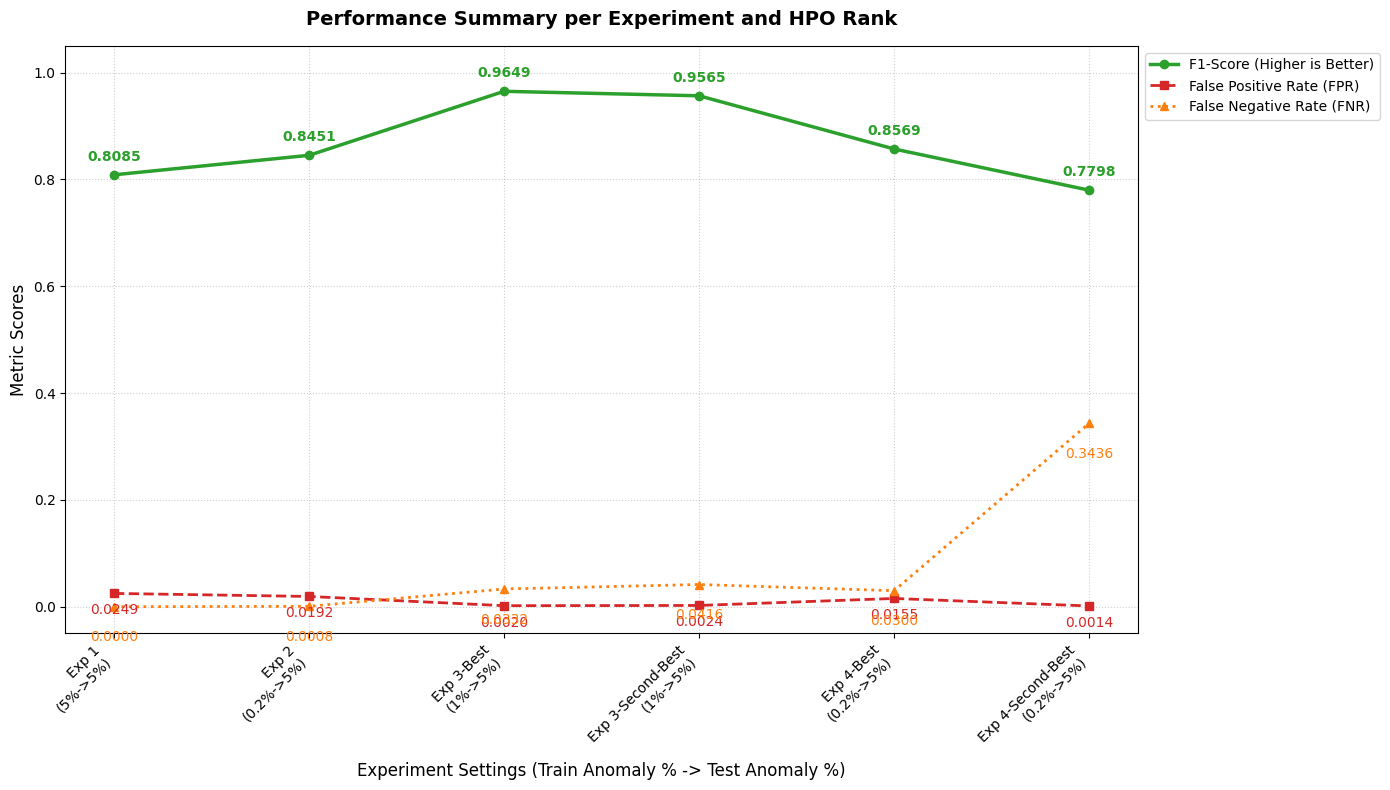

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Assume results_df is available from the notebook's execution context
# If not, uncomment and run: results_df = pd.read_csv(RESULTS_CSV_PATH)

plot_data = []

# Process Experiments 1 and 2 (Default rank only)
for exp_id in [1, 2]:
    # Filter for the current experiment and 'Default (No HPO)' rank
    exp_rank_df = results_df[(results_df["Experiment"] == exp_id) &
                             (results_df["HPORank"] == "Default (No HPO)")].copy()
    if not exp_rank_df.empty:
        # Find the row with the maximum F1 score within this group
        best_row = exp_rank_df.loc[exp_rank_df["F1"].idxmax()]
        plot_data.append({
            'experiment_label': f'Exp {exp_id}\n({best_row["TrainSet"]}->{best_row["TestSet"]})',
            'f1': best_row['F1'],
            'fpr': best_row['FPR'],
            'fnr': best_row['FNR'],
            'rank': best_row['HPORank']
        })

# Process Experiments 3 and 4 (Best (Rank 1) and Second-Best (Rank 2))
for exp_id in [3, 4]:
    for hpo_rank in ["Best (Rank 1)", "Second-Best (Rank 2)"]:
        # Filter for the current experiment and HPO rank
        exp_rank_df = results_df[(results_df["Experiment"] == exp_id) &
                                 (results_df["HPORank"] == hpo_rank)].copy()
        if not exp_rank_df.empty:
            # Find the row with the maximum F1 score within this group
            best_row = exp_rank_df.loc[exp_rank_df["F1"].idxmax()]
            plot_data.append({
                'experiment_label': f'Exp {exp_id}-{hpo_rank.split(" ")[0]}\n({best_row["TrainSet"]}->{best_row["TestSet"]})',
                'f1': best_row['F1'],
                'fpr': best_row['FPR'],
                'fnr': best_row['FNR'],
                'rank': best_row['HPORank']
            })
        else:
            print(f"Warning: No data found for Experiment {exp_id} with HPO Rank '{hpo_rank}'")


# Prepare data for plotting
experiments_labels = [d['experiment_label'] for d in plot_data]
f1_scores = [d['f1'] for d in plot_data]
fpr_values = [d['fpr'] for d in plot_data]
fnr_values = [d['fnr'] for d in plot_data]

plt.figure(figsize=(14, 8)) # Increased figure size for more data points

# Plotting F1-Score on primary y-axis
plt.plot(experiments_labels, f1_scores, marker='o', color='#2ca02c', linewidth=2.5, label='F1-Score (Higher is Better)')

# Plotting Error Rates (FPR & FNR)
plt.plot(experiments_labels, fpr_values, marker='s', color='#d62728', linestyle='--', linewidth=2, label='False Positive Rate (FPR)')
plt.plot(experiments_labels, fnr_values, marker='^', color='#ff7f0e', linestyle=':', linewidth=2, label='False Negative Rate (FNR)')

# Adding Value Labels onto the Graph
for i, txt in enumerate(f1_scores):
    plt.annotate(f'{txt:.4f}', (experiments_labels[i], f1_scores[i]), textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold', color='#2ca02c')
for i, txt in enumerate(fpr_values):
    plt.annotate(f'{txt:.4f}', (experiments_labels[i], fpr_values[i]), textcoords="offset points", xytext=(0,-15), ha='center', color='#d62728')
for i, txt in enumerate(fnr_values):
    plt.annotate(f'{txt:.4f}', (experiments_labels[i], fnr_values[i]), textcoords="offset points", xytext=(0,-25), ha='center', color='#ff7f0e')

plt.title('Performance Summary per Experiment and HPO Rank', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Experiment Settings (Train Anomaly % -> Test Anomaly %)', fontsize=12)
plt.ylabel('Metric Scores', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1)) # Moved legend outside to avoid overlap
plt.ylim(-0.05, 1.05)

plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout()
plt.show()

### Print HPO Performance Metrics
This cell prints a detailed breakdown of the F1-Score, FPR, and FNR for the 'Best (Rank 1)' and 'Second-Best (Rank 2)' HPO configurations across different experiments.

In [ ]:
print("Performance metrics for Best (Rank 1) and Second-Best (Rank 2) HPO configurations:")
for item in plot_data:
    if item['rank'] in ["Best (Rank 1)", "Second-Best (Rank 2)"]:
        print(f"Experiment: {item['experiment_label']}, Rank: {item['rank']}")
        print(f"  F1-Score: {item['f1']:.4f}")
        print(f"  FPR: {item['fpr']:.4f}")
        print(f"  FNR: {item['fnr']:.4f}")
        print("-" * 30)

Performance metrics for Best (Rank 1) and Second-Best (Rank 2) HPO configurations:
Experiment: Exp 3-Best
(1%->5%), Rank: Best (Rank 1)
  F1-Score: 0.9649
  FPR: 0.0020
  FNR: 0.0332
------------------------------
Experiment: Exp 3-Second-Best
(1%->5%), Rank: Second-Best (Rank 2)
  F1-Score: 0.9565
  FPR: 0.0024
  FNR: 0.0416
------------------------------
Experiment: Exp 4-Best
(0.2%->5%), Rank: Best (Rank 1)
  F1-Score: 0.8569
  FPR: 0.0155
  FNR: 0.0300
------------------------------
Experiment: Exp 4-Second-Best
(0.2%->5%), Rank: Second-Best (Rank 2)
  F1-Score: 0.7798
  FPR: 0.0014
  FNR: 0.3436
------------------------------


### Display Best and Second-Best HPO Parameters
This cell extracts and displays the hyperparameter configurations for the 'Best (Rank 1)' and 'Second-Best (Rank 2)' models from Experiments 3 and 4, along with their associated performance metrics.

In [ ]:
import json
import pandas as pd # Import pandas for DataFrame display

print("\nBest and Second-Best HPO Parameters:")

# Filter for Experiments 3 and 4 and the desired HPO Ranks
hpo_filtered_df = results_df[
    (results_df["Experiment"].isin([3, 4])) &
    (results_df["HPORank"].isin(["Best (Rank 1)", "Second-Best (Rank 2)"]))
].copy()

# Sort to ensure consistent output, e.g., by Experiment then by HPO Rank
hpo_filtered_df.sort_values(by=["Experiment", "HPORank"], inplace=True)

# List to collect data for the DataFrame
params_for_table = []

# Group by unique combinations of Experiment and HPO Rank to get distinct parameter sets
for (exp_id, hpo_rank), group in hpo_filtered_df.groupby(["Experiment", "HPORank"]):
    # Take the row with the best F1 score within this group, as parameters might be duplicated for different test sets
    # but we want the best performing set of parameters.
    row = group.loc[group['F1'].idxmax()]
    experiment_name = row["ExperimentName"]
    best_params_str = row["BestParams"]

    try:
        params = json.loads(best_params_str)
        # Create a dictionary for this row, including experiment, HPO rank, and performance metrics
        row_data = {
            "Experiment ID": exp_id,
            "Experiment Name": experiment_name,
            "HPO Rank": hpo_rank,
            "F1-Score": row["F1"],
            "FPR": row["FPR"],
            "FNR": row["FNR"],
        }
        row_data.update(params)
        params_for_table.append(row_data)
    except json.JSONDecodeError:
        print(f"  Error decoding parameters JSON string for Exp {exp_id} Rank {hpo_rank}.")

# Create a DataFrame from the collected parameters
if params_for_table:
    hpo_params_df = pd.DataFrame(params_for_table)
    # Reorder columns for better readability, putting identifiers and performance metrics first
    id_and_metrics_cols = ["Experiment ID", "Experiment Name", "HPO Rank", "F1-Score", "FPR", "FNR"]
    param_cols = [col for col in hpo_params_df.columns if col not in id_and_metrics_cols]
    hpo_params_df = hpo_params_df[id_and_metrics_cols + param_cols]
    display(hpo_params_df)
else:
    print("No HPO parameters found for display.")


Best and Second-Best HPO Parameters:


,Experiment ID,Experiment Name,HPO Rank,F1-Score,FPR,FNR,encoding_dim,hidden_dim,n_hidden_layers,learning_rate,dropout,l2_reg
0,3,"Optimized (All Features, With HPO)",Best (Rank 1),0.964870,0.001958,0.0332,48,192,1,0.000037,0.118002,0.000035
1,3,"Optimized (All Features, With HPO)",Second-Best (Rank 2),0.956487,0.002400,0.0416,48,192,1,0.000041,0.008397,0.000011
2,4,Optimized Feature-Selected (With HPO),Best (Rank 1),0.856890,0.015474,0.0300,48,256,1,0.000135,0.215257,0.000332
3,4,Optimized Feature-Selected (With HPO),Second-Best (Rank 2),0.779758,0.001432,0.3436,48,256,1,0.000494,0.037462,0.000330
